In [47]:
from dotenv import load_dotenv
import os
from mp_api.client import MPRester
import pandas as pd

load_dotenv()

API_KEY = os.getenv('API_KEY')

all_docs = []

with MPRester(API_KEY) as mpr:
    for element in ['Fe', 'Cr', 'Ni', 'Al', 'Cu', 'Mn', 'Mo']:
        docs = mpr.materials.summary.search(
            elements=[element],
            fields=[
                'material_id',
                'formula_pretty',
                'formation_energy_per_atom',
                'energy_above_hull',
                'band_gap',
                'composition',
            ]
        )
        all_docs.extend(docs)

print(f'Fetched {len(all_docs)} materials')

Retrieving SummaryDoc documents:   0%|          | 0/12956 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/6842 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/8299 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/7741 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/9856 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/14051 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/5393 [00:00<?, ?it/s]

Fetched 65138 materials


In [49]:
rows = []
for doc in all_docs:
    row = {
        'material_id': doc.material_id,
        'formula': doc.formula_pretty,
        'formation_energy': doc.formation_energy_per_atom,
        'energy_above_hull': doc.energy_above_hull,
        'band_gap': doc.band_gap,
    }
    # Add element fractions from composition
    for el, frac in doc.composition.fractional_composition.items():
        row[f'frac_{el}'] = float(frac)
    rows.append(row)
df = pd.DataFrame(rows).fillna(0)
print(df.shape)   # (rows, columns)
df.head(50)         # Shows first 5 rows

(65138, 90)


,material_id,formula,formation_energy,energy_above_hull,band_gap,frac_Fe,frac_O,frac_Cl,frac_H,frac_Zn,...,frac_Eu,frac_In,frac_Gd,frac_Pb,frac_Tc,frac_Ac,frac_Os,frac_Pa,frac_Xe,frac_Pm
0,mp-1245108,Fe,0.279455,0.279455,0.0000,1.000000,0.000000,0.00,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,mp-1194030,Fe,0.175289,0.175289,0.0000,1.000000,0.000000,0.00,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,mp-1271068,Fe,0.017070,0.017070,0.0000,1.000000,0.000000,0.00,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,mp-1271128,Fe,0.099135,0.099135,0.0000,1.000000,0.000000,0.00,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,mp-1096950,Fe,0.476699,0.476699,0.0000,1.000000,0.000000,0.00,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,mp-136,Fe,0.097806,0.097806,0.0000,1.000000,0.000000,0.00,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,mp-568345,Fe,0.761412,0.761412,0.0000,1.000000,0.000000,0.00,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,mp-150,Fe,0.148365,0.148365,0.0000,1.000000,0.000000,0.00,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,mp-13,Fe,0.000000,0.000000,0.0000,1.000000,0.000000,0.00,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,mp-1271198,Fe,0.054992,0.054992,0.0000,1.000000,0.000000,0.00,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [27]:
# How many rows and columns
print(df.shape)

(5393, 88)


In [29]:
# Column names and data types
print(df.dtypes)

material_id              str
formula                  str
formation_energy     float64
energy_above_hull    float64
band_gap             float64
                      ...   
frac_Sc              float64
frac_Ag              float64
frac_Np              float64
frac_Pu              float64
frac_Au              float64
Length: 88, dtype: object


In [30]:
# Summary Statistics
df.describe()

,formation_energy,energy_above_hull,band_gap,frac_Mo,frac_S,frac_O,frac_F,frac_Te,frac_Bi,frac_N,...,frac_Lu,frac_Tm,frac_Y,frac_Ga,frac_In,frac_Sc,frac_Ag,frac_Np,frac_Pu,frac_Au
count,5393.000000,5393.000000,5393.000000,5393.000000,5393.000000,5393.000000,5393.000000,5393.000000,5393.000000,5393.000000,...,5393.000000,5393.000000,5393.000000,5393.000000,5393.000000,5393.000000,5393.000000,5393.000000,5393.000000,5393.000000
mean,-1.193768,0.236714,0.911664,0.195288,0.069147,0.302429,0.013617,0.046410,0.002430,0.015897,...,0.000754,0.000713,0.002401,0.002884,0.000814,0.000924,0.001392,0.000158,0.000178,0.000106
std,1.218406,0.633827,1.229439,0.126317,0.153665,0.316668,0.089272,0.115943,0.028926,0.078759,...,0.013163,0.010591,0.019757,0.042484,0.009571,0.013482,0.014530,0.004876,0.005605,0.004150
min,-3.598722,0.000000,0.000000,0.006667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-2.185778,0.010851,0.000000,0.109091,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,-1.066054,0.076117,0.118900,0.166667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,-0.477956,0.206342,1.608500,0.250000,0.000000,0.631579,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,5.175656,5.272300,4.817800,1.000000,0.857143,0.836364,0.857143,0.666667,0.769231,0.666667,...,0.666667,0.285714,0.315789,0.837838,0.250000,0.500000,0.333333,0.222222,0.250000,0.250000


In [31]:
# How many materials are perfectly stable. Have energy_above_hull of zero
print((df['energy_above_hull'] == 0).sum())

867


In [32]:
# What is the average stability
print((df['energy_above_hull']).mean())

0.23671439667555905


In [34]:
# Are there any missing values
print(df.isnull().sum())

material_id          0
formula              0
formation_energy     0
energy_above_hull    0
band_gap             0
                    ..
frac_Sc              0
frac_Ag              0
frac_Np              0
frac_Pu              0
frac_Au              0
Length: 88, dtype: int64


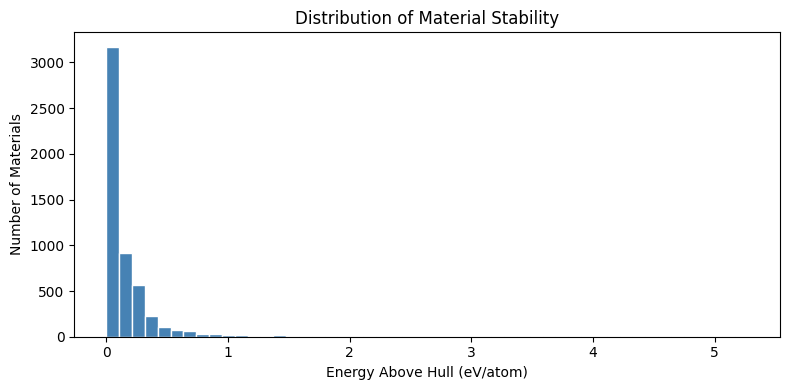

In [44]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.hist(df['energy_above_hull'], bins=50, color='steelblue', edgecolor='white')
plt.xlabel('Energy Above Hull (eV/atom)')
plt.ylabel('Number of Materials')
plt.title('Distribution of Material Stability')
plt.tight_layout()
plt.show()